In [2]:
import pandas as pd
import numpy as np
import itertools
from scipy.spatial.distance import pdist, squareform
from joblib import Parallel, delayed
import dask.dataframe as dd
import scanpy as sc
from scipy.sparse import csr_matrix, coo_matrix
from scipy.linalg import eigh
import torch
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import itertools


plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'


## Shuffle the labels of partial simulated cells

In [3]:
suffix = 'b2_c2_p49_d128_re5.0_rv1.5'

In [4]:
sim_ad_csr = sc.read_h5ad(f'sim_ad_{suffix}_safe.h5ad')

In [5]:
sim_ad_csr.obs['perturbation_true'] = sim_ad_csr.obs['perturbation'].copy()

In [6]:
shuffle_rate = 0.25
np.random.seed(0) # using 0 since 42 surprisingly leads to no shuffling for c0 test set!
shuffle_mask = (np.random.rand(len(sim_ad_csr)) < shuffle_rate) & (sim_ad_csr.obs['perturbation_true'] != 'control')
shuffle_labels = sim_ad_csr.obs['perturbation_true'].copy()
shuffle_labels[shuffle_mask] = np.random.permutation(shuffle_labels[shuffle_mask])
sim_ad_csr.obs['perturbation'] = shuffle_labels

In [7]:
true_labels = sim_ad_csr.obs['perturbation_true'].copy()
shuffle_labels = sim_ad_csr.obs['perturbation'].copy()
(shuffle_labels[shuffle_labels != 'control'] == true_labels[true_labels != 'control']).mean()

np.float64(0.7485204081632653)

In [8]:
sim_ad_csr.write_h5ad(f'sim_ad_{suffix}_impure.h5ad', compression='gzip')

In [9]:
split_df = pd.read_parquet(f'split_df_{suffix}.parquet')

<Axes: xlabel='perturbation_true', ylabel='perturbation'>

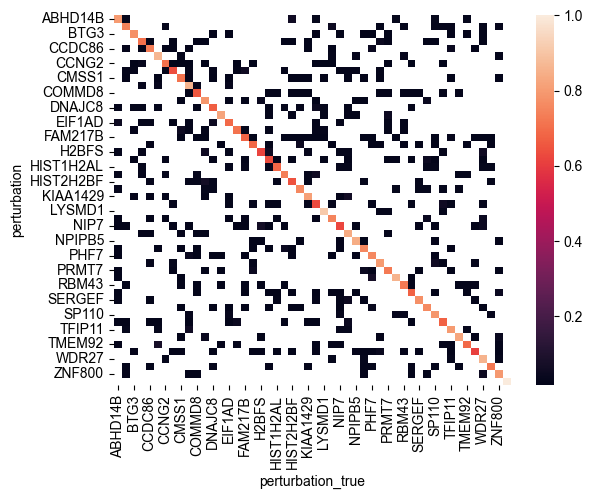

In [11]:
sns.heatmap(sim_ad_csr.obs.loc[
    split_df.query('split == "test" and subsplit == "c0"').index.values, 
    ['perturbation', 'perturbation_true']
].value_counts().unstack().transform(lambda x: x / x.sum(), axis=1))